# [INF0102] | LAB 6 - Exercice 2 - Prédiction du prix de DIAMANTS

## Auteur.e.s

## Objectifs de cet exercice

- L'objectif de cet exercice de TP est de vous offir une **révision des concepts *pythoniques*** appris au sein de votre cours **INF0102** en vue de votre **examen final**.

- Cet exercice offre une révision des concepts de **dictionnaires**, de manipulation d'un **fichier de données** (en format **`.csv`**), ainsi que l'analyse et à la visualisation de données avec **`numpy`**, **`pandas`** et **`matplotlib`**.

- Vous arriverez également à construire différents modèles de régression de votre choix pour prédire le prix d'un diamant basé sur ses caractéristiques.

## Prérequis

- Python, plus particulièrement l'nstallation des bibliothèques **`numpy`**, **`pandas`**, **`matplotlib`** et **`scikit-learn`**.

- Pour installer ces librairies, utilisez la commande suivante au sein de votre terminal: 
    **```pip install -r requirements.txt```**

- Assurez-vous d'avoir un alias vers **`pip3`** si **`pip`** n'est pas reconnu, voire vérifier l'installation de **`pip`** avant d'effectuer cette commande.

- Assurez-vous également que votre invité de commandes de votre terminal soit situé à la **racine** du dossier du travail pratique en question.

## Développement

### [Partie 0] | Importations des librairies et configuration

- **Vous n'avez rien à développer pour cette partie.** Vous devez simplement l'interpréter en exécutant le prochain bloc de code.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.neural_network import MLPRegressor

# Configuration de pandas pour ignorer les avertissements
pd.set_option('mode.chained_assignment', None)

### [Partie 1] | Chargement et inspection des données [TODO]

- 1.1. [TODO] Charger le jeu de données **`.csv`** en **`DataFrame`** de **`pandas`**. Vous devez utiliser la méthode **[`read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)** de **`pandas`**.

- 1.2. [TODO] Inspecter le jeu de données. Vous devez afficher à l'écran les premières lignes du jeu de données, une description statistique et les informations reliées au jeu de données en question. Vous devriez utiliser respectivement les méthodes **[`head`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html)** et **[`describe`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)** de **pandas** sur votre jeu de données (**`DataFrame`**).

In [2]:
"""
1.1. [TODO]
"""
def load_data(filepath: str) -> pd.DataFrame:
    """
    Charge un fichier CSV en un DataFrame de pandas.
    :param filepath:    Chemin vers le fichier CSV.
    :return:            DataFrame de pandas.
    """
    diamonds = pd.read_csv(filepath)
    # La 1re colonne du CSV est un index sans nom (résidu d'export R) : on la retire,
    # sinon elle serait scalée et utilisée comme une fausse caractéristique du modèle.
    return diamonds.drop(columns=[col for col in diamonds.columns if col.startswith('Unnamed')])

    
"""
1.2. [TODO]
"""
def inspect_data(diamonds: pd.DataFrame) -> None:
    """
    Efectue une inspection initiale du jeu de données.
    Affiche les premières lignes, la description statistique et les informations du jeu de données.
    :param diamonds: Jeu de données à inspecter.
    """
    print("=== Premières lignes du jeu de données ===")
    print(diamonds.head())
    
    
    print("\n=== Description statistique ===")
    print(diamonds.describe())


### [Partie 2] | Prétraitement du jeu de données [TODO]

- 2.1. [TODO] Convertir les colonnes **catégoriques** **`cut`**, **`color`** et **`clarity`** en format **numérique** à l'aide d'un **`LabelEncoder`**. Vous devez utiliser la méthode [**`fit_transform`**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) sur votre **`LabelEncoder`**.

- 2.2. [TODO] Éliminer les colonnes redondantes et fortement corrélées **`x`**, **`y`** et **`z`**. Vous devez utiliser la méthode [**`drop`**](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) sur votre **`DataFrame`**.

- 2.3. [TODO] Transformer les prix (**`price`**) sur une échelle **logarithmique** pour réduire l'asymétrie. Vous devez utiliser la méthode [**`log`**](https://numpy.org/doc/stable/reference/generated/numpy.log.html) de **`numpy`** sur votre colonne des prix (**`price`**) de diamants.

- 2.4. [TODO] Normaliser les caractéristiques à l'aide d'un **`StandardScaler`**. Vous devez utiliser la méthode [**`fit_transform`**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) sur votre **`StandardScaler`**.

In [3]:
"""
2. [TODO]
"""
def preprocess_data(diamonds: pd.DataFrame) -> pd.DataFrame:
    """
    Pré-traite les données en convertissant les catégories en numérique,
    en éliminant les colonnes redondantes, et en traitant les valeurs aberrantes.
    :param diamonds: DataFrame de pandas contenant les données.
    :return: DataFrame pré-traité.
    """
    """
    2.1. [TODO]
    """
    label_encoder: LabelEncoder = LabelEncoder()

    for column in ['cut', 'color', 'clarity']:
        diamonds[column]=label_encoder.fit_transform(diamonds[column])

    """
    2.2. [TODO]
    """
    diamonds = diamonds.drop(['x','y','z'],axis=1)

        
    """
    2.3. [TODO]
    """
    diamonds['price'] = np.log(diamonds['price'])  


    # ----- FIN DU DÉVELOPPEMENT DE 2.3. -----
    # Séparation des caractéristiques et de la cible
    features:   pd.DataFrame = diamonds.drop('price', axis=1)
    target:     pd.DataFrame = diamonds['price']
    # ----- ^ NE PAS TOUCHER ^ -----


    """
    2.4. [TODO]
    """
    scaler: StandardScaler = StandardScaler()
    features_scaled: pd.DataFrame = scaler.fit_transform(features)


    # ----- FIN DU DÉVELOPPEMENT DE 2.4. -----
    # Concaténation des caractéristiques normalisées et de la cible
    diamonds_preprocessed: pd.DataFrame = pd.DataFrame(
        features_scaled, 
        columns=features.columns
    )
    diamonds_preprocessed['price'] = target.reset_index(drop=True)

    return diamonds_preprocessed
    # ----- ^ NE PAS TOUCHER ^ -----

### [Partie 3] | Implémentation de la fonction de perte [TODO]

- 3.1. [TODO] Implémenter la fonction de perte **`RMSE`** (la racine de l'erreur quadratique moyenne [**`MSE`**]). Vous devez appliquer la racine sur le retour de la méthode **[`mean_squared_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)** de **`sklearn.metrics`**.

In [4]:
"""
3.1. [TODO]
"""
def calculate_rmse(y_true, y_pred) -> float:
    """
    Calcule la racine carrée de l'erreur quadratique moyenne.
    :param y_true:  Valeurs réelles.
    :param y_pred:  Valeurs prédites.
    :return:        Valeur RMSE.
    """
    return   mean_squared_error(y_true,y_pred) ** 0.5

### [Partie 4] | Réingénierie de caractéristiques [TODO]

- 4.1. [TODO] Ajoutez une nouvelle colonne au sein de votre trame de données nommée **`volume`**. Cette nouvelle colonne doit être le produire de **`carat`**, **`depth`** et **`table`**.

In [5]:
"""
4.1. [TODO]
"""

def feature_engineering(diamonds: pd.DataFrame) -> pd.DataFrame:
    """
    Ajoute une combinaison de caractéristiques qui pourrait être pertinente pour la prédiction.
    Crée une nouvelle colonne 'volume' qui est le produit de 'carat', 'depth' et 'table'.
    :param diamonds:    DataFrame de pandas.
    :return:            DataFrame avec la réingénierie d'attributs.
    """
    diamonds['volume']=diamonds['carat']*diamonds['depth']*diamonds['table']

    return diamonds 

### [Partie 5] | Analyses graphiques [TODO]

- 5.1. [TODO] À l'aide de **`seaborn`** et **`matplotlib`**, affichez un **histogramme** ([**`histplot`**](https://seaborn.pydata.org/generated/seaborn.histplot.html)) de la distribution du **nombre de diamants** selon le **prix** (**`price`**) préalablement transformé (sur une échelle logarithmique).

- 5.2. [TODO] À l'aide de **`seaborn`** et **`matplotlib`**, affichez un **nuage de points** ([**`scatterplot`**](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)) de la relation du **prix** (**`price`**) des diamants en fonction du **carat** (**`carat`**).

- 5.3. [TODO] À l'aide de **`seaborn`** et **`matplotlib`**, affichez un **diagramme à moustaches** ([**`boxplot`**](https://seaborn.pydata.org/generated/seaborn.boxplot.html)) du **prix** (**`price`**) selon la **qualité de coupe** (**`cut`**).

In [6]:
"""
5. [TODO]
"""
def analyze_data(diamonds):
    """
    Réalise une analyse approfondie du dataset.
    Inclue la distribution des prix transformés des diamants.
    Inclue la relation entre le carat et le prix.
    Inclue le prix par qualité de coupe.
    :param diamonds: DataFrame de pandas pré-traité.
    """
    """
    5.1. [TODO]
    """
    plt.figure(figsize=(8, 6))
    sns.histplot(data=diamonds, x='price')
    plt.title('Distribution du prix (échelle logarithmique)')
    plt.tight_layout()
    plt.savefig('../images/price_distribution.png', dpi=120)
    plt.show()


    """
    5.2. [TODO]
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=diamonds, x='carat', y='price')
    plt.title('Prix en fonction du carat')
    plt.tight_layout()
    plt.savefig('../images/carat_vs_price.png', dpi=120)
    plt.show()


    """
    5.3. [TODO]
    """
    plt.figure(figsize=(8, 6))
    # 'cut' a été encodé numériquement puis normalisé lors du prétraitement (Partie 2) ;
    # on remappe vers les étiquettes lisibles (ordre alphabétique = ordre du LabelEncoder)
    # pour que le graphique reste interprétable.
    cut_labels = ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']
    cut_mapping = dict(zip(sorted(diamonds['cut'].unique()), cut_labels))
    sns.boxplot(data=diamonds, x=diamonds['cut'].map(cut_mapping), y='price', order=cut_labels)
    plt.xlabel('cut')
    plt.title('Prix par qualité de coupe')
    plt.tight_layout()
    plt.savefig('../images/price_by_cut_boxplot.png', dpi=120)
    plt.show()

### [Partie 6] | Entraînement des modèles [TODO]

- 6.1. [TODO] À l'aide de **`scikit-learn`**, définissez au moins **3** modèles de régression différents de votre choix au sein d'un dictionnaire. Les clefs dudit dictionnaire représentent les noms des modèles implémentés, alors que les valeurs initialisent les modèles en question.

> Vous avez le choix entre :

- [**`Régression Ridge [Ridge]`**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- [**`Forêt Aléatoire [RandomForestRegressor]`**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- [**`Augmentation de gradient [GradientBoostingRegressor]`**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
- [**`AdaBoostRegressor`**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html)
- [**`Ensachage [BaggingRegressor]`**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html)
- [**`Réseau de neurones [MLPRegressor]`**](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html)

> Vous pouvez explorer les **hyperparamètres** de ces modèles, comme le nombre d'estimateurs (**`n_estimators`**). Amusez-vous ! Il n'y a pas de contrainte à ce niveau.

In [7]:
"""
6. [TODO]
"""
def train_models(x_train, y_train, x_test, y_test) -> dict:
    """
    Entraîne plusieurs modèles de régression et évalue leurs performances sur l'ensemble de test.
    :param X_train: Caractéristiques d'entraînement.
    :param y_train: Cible d'entraînement.
    :param X_test: Caractéristiques de test.
    :param y_test: Cible de test.
    :return: Dictionnaire des modèles avec leur MSE et graphiques des performances.
    """
    """
    6.1. [TODO]
    """
    models: dict[str, Ridge | RandomForestRegressor | GradientBoostingRegressor | AdaBoostRegressor | BaggingRegressor | MLPRegressor | any] = \
    {
        'Ridge': Ridge(),
        'RandomForestRegressor'  :RandomForestRegressor(),
        'GradientBoostingRegressor':GradientBoostingRegressor(),
        'AdaBoostRegressor' :AdaBoostRegressor(),
        'Ensachage': BaggingRegressor(),
        'MLPRegressor': MLPRegressor(),
    }
    

    # ----- FIN DU DÉVELOPPEMENT DE 2.3. -----
    results: dict = {}

    for name, model in models.items():
        model.fit(x_train, y_train)
        y_pred_train = model.predict(x_train)
        y_pred_test = model.predict(x_test)
        rmse_train = calculate_rmse(y_train, y_pred_train)
        rmse_test = calculate_rmse(y_test, y_pred_test)
        results[name] = {'RMSE Train': rmse_train, 'RMSE Test': rmse_test}
        print(f"{name} - RMSE Train: {rmse_train} | RMSE Test: {rmse_test}")

    return results
    # ----- ^ NE PAS TOUCHER ^ -----

### [Partie 7] | Comparaison des performances des modèles sélectionnés

- **Vous n'avez rien à développer pour cette partie.** Vous devez simplement l'interpréter en exécutant le prochain bloc de code.

In [8]:
def plot_model_comparisons(results: dict) -> None:
    """
    Affiche un graphique comparatif des performances des modèles.
    :param results: Dictionnaire contenant les MSE des modèles.
    """
    names = list(results.keys())
    rmse_train = [res['RMSE Train'] for res in results.values()]
    rmse_test = [res['RMSE Test'] for res in results.values()]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 8))
    rects1 = ax.bar(x - width/2, rmse_train, width,
                    label='Train', color='skyblue')
    rects2 = ax.bar(x + width/2, rmse_test, width,
                    label='Test', color='salmon')

    ax.set_ylabel('RMSE')
    ax.set_title('RMSE par modèle')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45)
    ax.legend()

    fig.tight_layout()
    fig.savefig('../images/model_comparison_rmse.png', dpi=120)
    plt.show()

### [Partie 8] | Exécution complète

- **Vous n'avez rien à développer pour cette partie.** Vous devez simplement l'interpréter en exécutant le prochain bloc de code.

- Assurez-vous d'avoir ouvert le dossier de l'exercice au sein de votre éditeur de code de préférence. Sinon, veuillez modifier votre variable de chemin de fichier (**`FILE_PATH`**) pour charger sans erreur votre jeu de données.

=== Premières lignes du jeu de données ===
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

=== Description statistique ===
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     

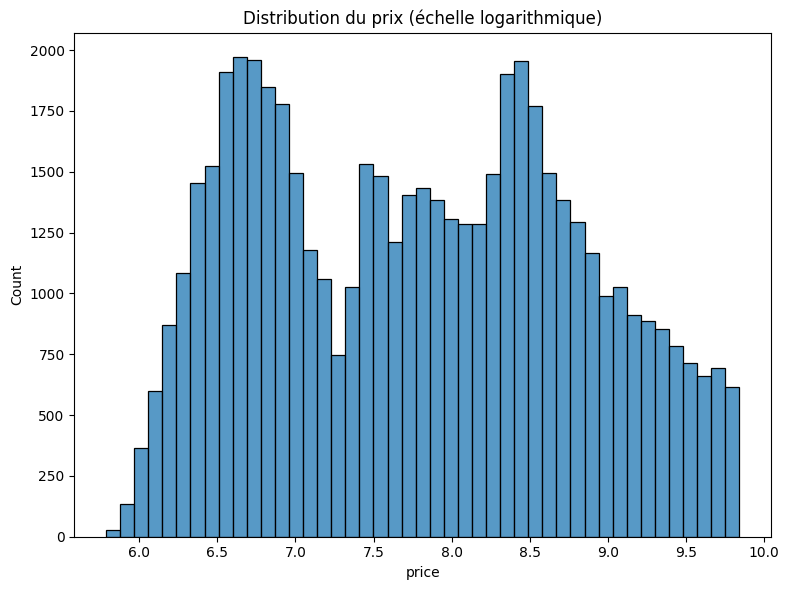

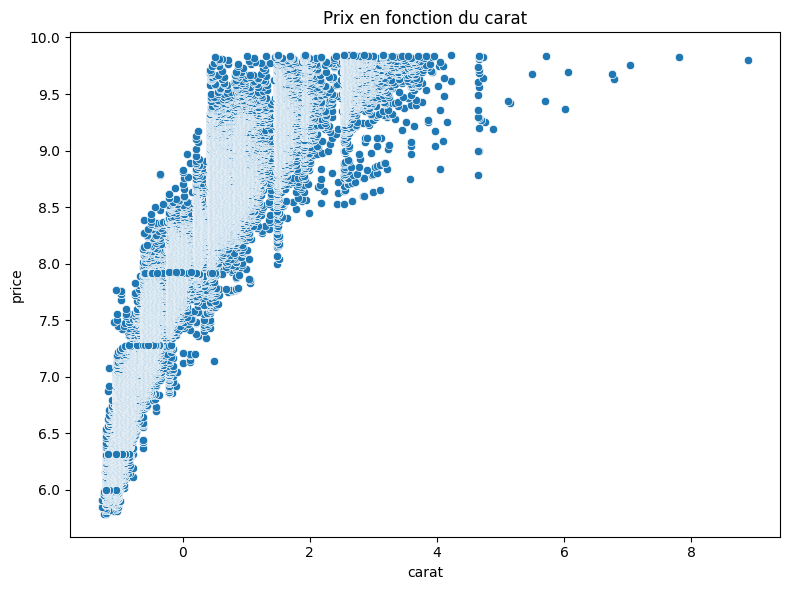

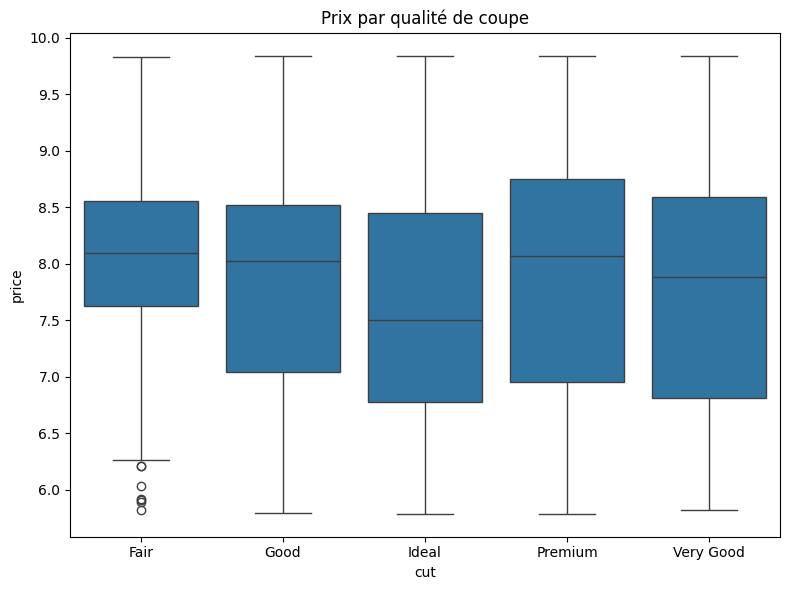

Ridge - RMSE Train: 0.36762775741648146 | RMSE Test: 0.3694198081715381
RandomForestRegressor - RMSE Train: 0.05212566074782523 | RMSE Test: 0.11122984038328172
GradientBoostingRegressor - RMSE Train: 0.11442276985571948 | RMSE Test: 0.11599370185423569
AdaBoostRegressor - RMSE Train: 0.2492131790278004 | RMSE Test: 0.251046982071429
Ensachage - RMSE Train: 0.05661902097809258 | RMSE Test: 0.11420974075047
MLPRegressor - RMSE Train: 0.11449934962245052 | RMSE Test: 0.1182222158732541


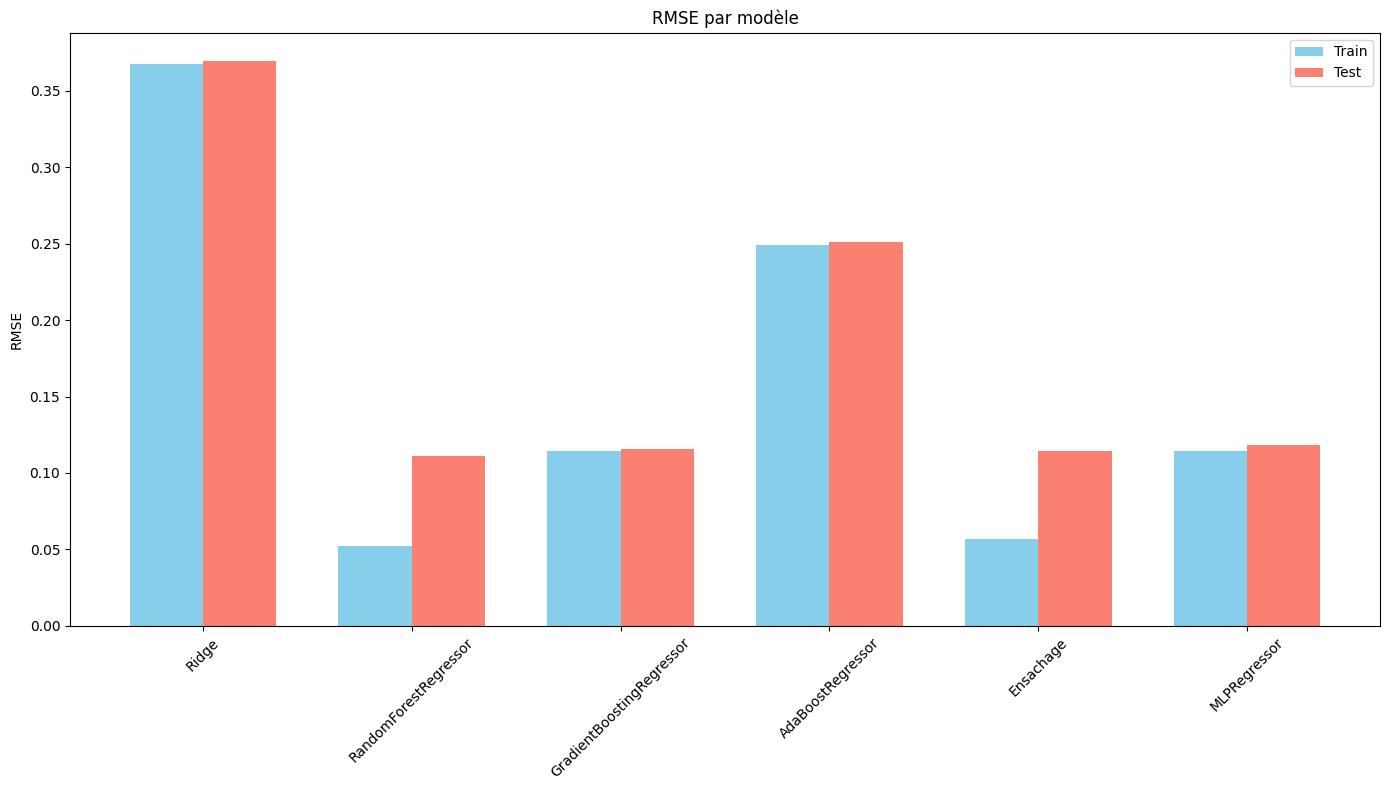

In [9]:
# Chemin vers le fichier du jeu de données
FILE_PATH: str = '../data/diamonds.csv'  # À modifier, au besoin !


# [Partie 1] | Chargement et inspection des données
DIAMONDS: pd.DataFrame = load_data(FILE_PATH)
inspect_data(DIAMONDS)


# [Partie 2] | Prétraitement du jeu de données
DIAMONDS = preprocess_data(DIAMONDS)


# [Partie 4] | Réingénierie des caractéristiques
DIAMONDS = feature_engineering(DIAMONDS)


# [Partie 5] | Analyses graphiques
analyze_data(DIAMONDS)


# [Partie 6] | Entraînement des modèles
# Préparation des données pour le modèle
features = DIAMONDS.drop('price', axis=1)
target = DIAMONDS['price']
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# Entraînement et évaluation des modèles
RESULTS: dict = train_models(X_train, y_train, X_test, y_test)


# [Partie 7] | Comparaison des performances des modèles sélectionnés
plot_model_comparisons(RESULTS)